# Halo Occupation Distribution

`<N_gal | M_halo>` computed with the two-histogram method: galaxy counts binned by host-halo mass, divided by tree-halo counts (which include halos with zero galaxies).

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

import galform_analysis
from galform_analysis import set_base_dir, get_base_dir, SimulationConfig, load_redshift_mapping

mpl.setconfig()

# Configure the path to your GALFORM output directory once per session:
# set_base_dir('/cosma5/data/durham/<user>/Galform_Out/L800/model')
BASE_DIR = str(get_base_dir())
SIM = 'L800'

## HOD for a single subvolume

In [2]:
from galform_analysis.analysis.mass_functions.hod import (
    hod_given_redshift_and_subvolume,
    avg_hod_given_redshift_and_subvolumes,
    hods_given_redshifts_and_subvolume,
)
from galform_analysis.config import get_snapshot_redshift
import os

iz_path = os.path.join(BASE_DIR, 'iz155')
res = hod_given_redshift_and_subvolume(iz_path, ivol=0, galaxy_stellar_mass_min=1e9)
print(f"z={res['z']:.4f},  n_halos={res['n_halos']:,},  n_galaxies={res['n_galaxies']:,}")

z=1.4955,  n_halos=138,238,  n_galaxies=3,605


## Average over subvolumes with central/satellite decomposition

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\o'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_3825483/2224583997.py:20: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f'HOD  z={z:.3f},  $M_\star > 10^9\,\mathrm{{M}}_\odot/h$')
/tmp/ipykernel_3825483/2224583997.py:20: SyntaxWarning: invalid escape sequence '\o'
  ax.set_title(f'HOD  z={z:.3f},  $M_\star > 10^9\,\mathrm{{M}}_\odot/h$')


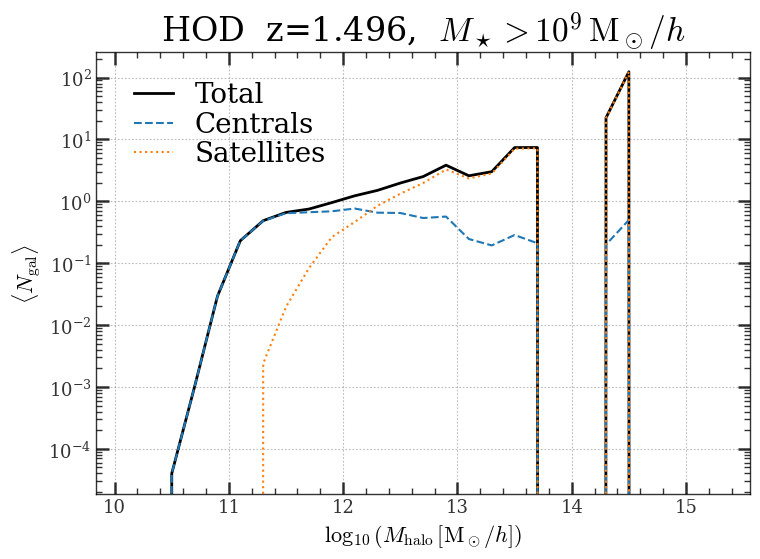

In [3]:
IZ_NUM = 155
IVOLS  = list(range(4))

z = get_snapshot_redshift(f'iz{IZ_NUM}', SIM)
res = avg_hod_given_redshift_and_subvolumes(
    IZ_NUM, IVOLS,
    base_dir=BASE_DIR,
    galaxy_stellar_mass_min=1e9,
)

fig, ax = plt.subplots()
ax.plot(res['centers'], res['mean_occupation'], 'k-',  lw=2,   label='Total')
if res['mean_central'] is not None:
    ax.plot(res['centers'], res['mean_central'],   'C0--', lw=1.5, label='Centrals')
if res['mean_satellite'] is not None:
    ax.plot(res['centers'], res['mean_satellite'],  'C1:',  lw=1.5, label='Satellites')
ax.set_yscale('log')
ax.set_xlabel(r'$\log_{{10}}(M_{{\rm halo}}\,[\mathrm{{M}}_\odot/h])$')
ax.set_ylabel(r'$\langle N_{{\rm gal}}\rangle$')
ax.set_title(f'HOD  z={z:.3f},  $M_\star > 10^9\,\mathrm{{M}}_\odot/h$')
ax.legend()
fig.tight_layout()
plt.show()

## HOD across multiple snapshots

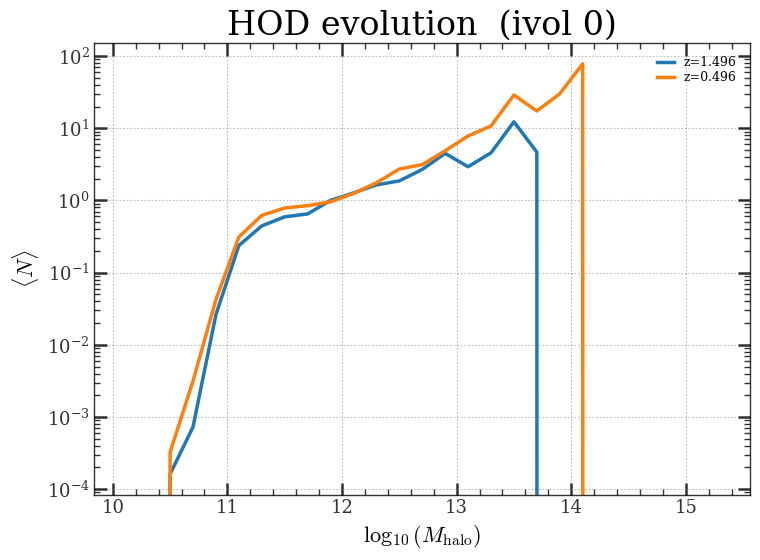

In [4]:
IZ_NUMS = [82, 120, 155, 207]
IVOL    = 0

df_hod, results = hods_given_redshifts_and_subvolume(
    IVOL, IZ_NUMS, base_dir=BASE_DIR, galaxy_stellar_mass_min=1e9
)
if df_hod is not None:
    import polars as pl
    fig, ax = plt.subplots()
    for (z_val,), grp in df_hod.group_by('z', maintain_order=True):
        ax.plot(grp['log_M'], grp['mean_occupation'], label=f'z={z_val:.3f}')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\log_{{10}}(M_{{\rm halo}})$')
    ax.set_ylabel(r'$\langle N \rangle$')
    ax.set_title('HOD evolution  (ivol 0)')
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()